# 📊 Parte 2 - Análise de Medalhas Olímpicas por Continente (1896-2024)

## 🎯 Objetivos

- 2.1 - Distribuição total de medalhas por continente
- 2.2 - Crescimento da representação ao longo do tempo
- 2.3 - Participação feminina por continente
- 2.4 - Modalidades mais fortes por continente
- 2.5 - Crescimento nas medalhas entre 1896 e 2024

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime
import json
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
plt.rcParams['figure.figsize'] = (14,8)
plt.rcParams['font.size'] = 11
%matplotlib inline
print('✅ OK!')

✅ OK!


In [48]:
BASE_PATH=Path('../..')
RAW_PATH=BASE_PATH/'raw'
BRONZE_PATH=BASE_PATH/'bronze'/'parte2'
GOLD_PATH=BASE_PATH/'gold'/'parte2'
METADATA_PATH=BASE_PATH/'metadata'/'parte2'
OUTPUTS_PATH=BASE_PATH/'outputs'
for p in [BRONZE_PATH,GOLD_PATH,METADATA_PATH,(OUTPUTS_PATH/'figures'),(OUTPUTS_PATH/'tables')]:p.mkdir(parents=True,exist_ok=True)
print('✅ Paths!')

✅ Paths!


In [49]:
import sys
sys.path.insert(0,str(BASE_PATH/'code'/'parte2'))
from noc_to_continent import get_continent,get_continents_summary
print('✅ Mapeamento!')
for c,n in sorted(get_continents_summary().items()):print(f'{c}:{n}')

✅ Mapeamento!
Américas:42
Diversos:3
Europa:60
Oceania:18
África:54
Ásia:44


## 📥 Carregamento e Integração

In [50]:
print('CARREGANDO...')
df_hist_results=pd.read_csv(RAW_PATH/'Olympics_1896_2022'/'world_olympedia_olympics_athlete_event_result.csv')
df_hist_athletes=pd.read_csv(RAW_PATH/'Olympics_1896_2022'/'world_olympedia_olympics_athlete_bio.csv')
df_hist_games=pd.read_csv(RAW_PATH/'Olympics_1896_2022'/'world_olympedia_olympics_game.csv')
df_paris=pd.read_csv(RAW_PATH/'Olympics_Paris2024'/'medallists.csv')
print(f'✅ {len(df_hist_results):,} + {len(df_paris):,}')

CARREGANDO...


✅ 316,834 + 2,315


In [51]:
print('INTEGRANDO...')
df_h=df_hist_results[df_hist_results['medal'].notna()].copy()
# Prepare df_hist_games with correct column names and extract season
df_games_prep=df_hist_games[['edition_id','year','edition']].copy()
df_games_prep['game_season']=df_games_prep['edition'].apply(lambda x: 'Summer' if 'Summer' in str(x) else 'Winter')
df_games_prep=df_games_prep.rename(columns={'year':'game_year'})
# Merge with games data
df_h=df_h.merge(df_games_prep[['edition_id','game_year','game_season']],on='edition_id')
# Merge with athletes data (sex column, not athlete_sex)
df_h=df_h.merge(df_hist_athletes[['athlete_id','sex']],on='athlete_id',how='left')
df_h=df_h.rename(columns={'sex':'athlete_sex','sport':'event_discipline'})
df_h['continent']=df_h['country_noc'].apply(get_continent)
df_p=df_paris.copy()
df_p['game_year']=2024
df_p['game_season']='Summer'
df_p['continent']=df_p['country_code'].apply(get_continent)
df_p=df_p.rename(columns={'country_code':'country_noc','medal_type':'medal','discipline':'event_discipline','gender':'athlete_sex'})
cols=['country_noc','medal','event_discipline','athlete_sex','game_year','game_season','continent']
df_medals=pd.concat([df_h[cols],df_p[cols]],ignore_index=True)
df_medals=df_medals[df_medals['continent']!='Desconhecido']
df_medals['medal']=df_medals['medal'].str.upper()
print(f'✅ {len(df_medals):,} medalhas')
df_medals.to_parquet(BRONZE_PATH/'medals_integrated.parquet',index=False)
print('💾 Bronze')

INTEGRANDO...
✅ 46,992 medalhas
💾 Bronze


## 📊 2.1 - Distribuição de Medalhas por Continente

2.1 - DISTRIBUIÇÃO

Total por continente:
Europa      : 29,209
Américas    : 10,532
Ásia        : 4,463
Oceania     : 2,063
África      : 720
Diversos    : 5

💾 Gráfico: parte2_pizza_continente.png


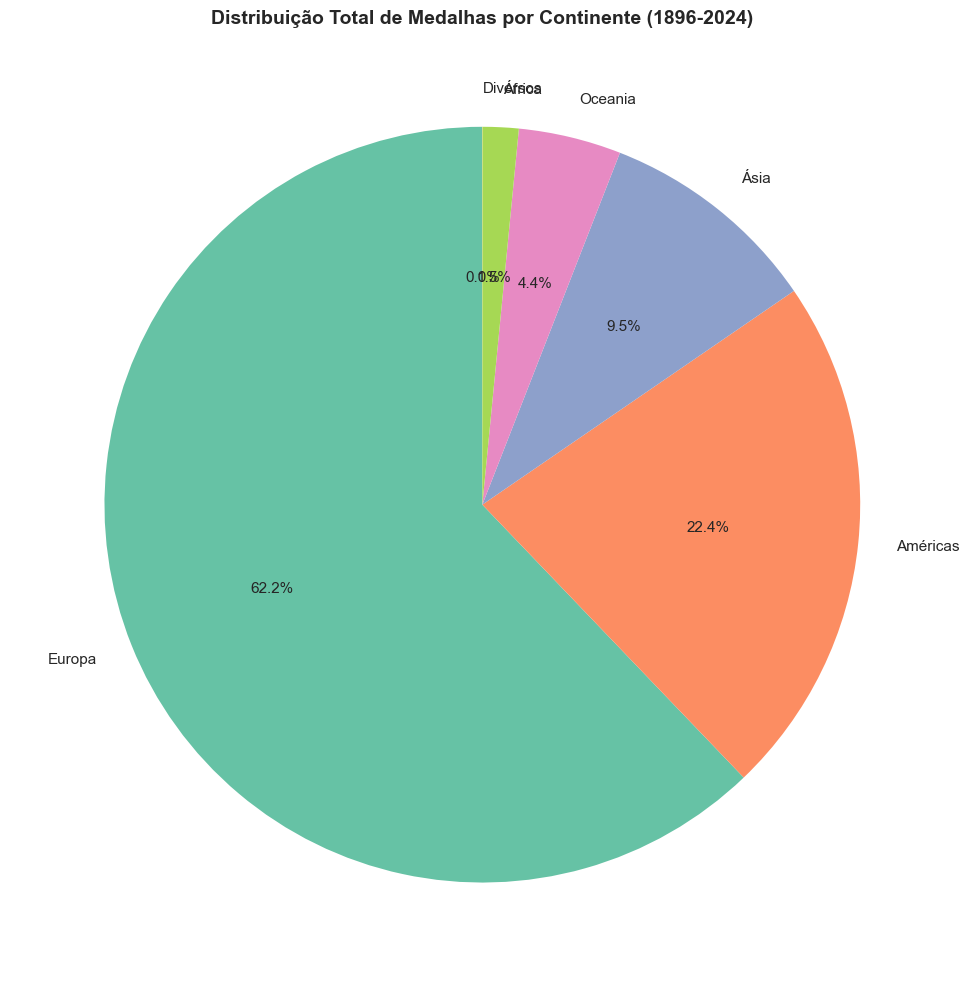

💾 Gráfico: parte2_evolucao_continente.png


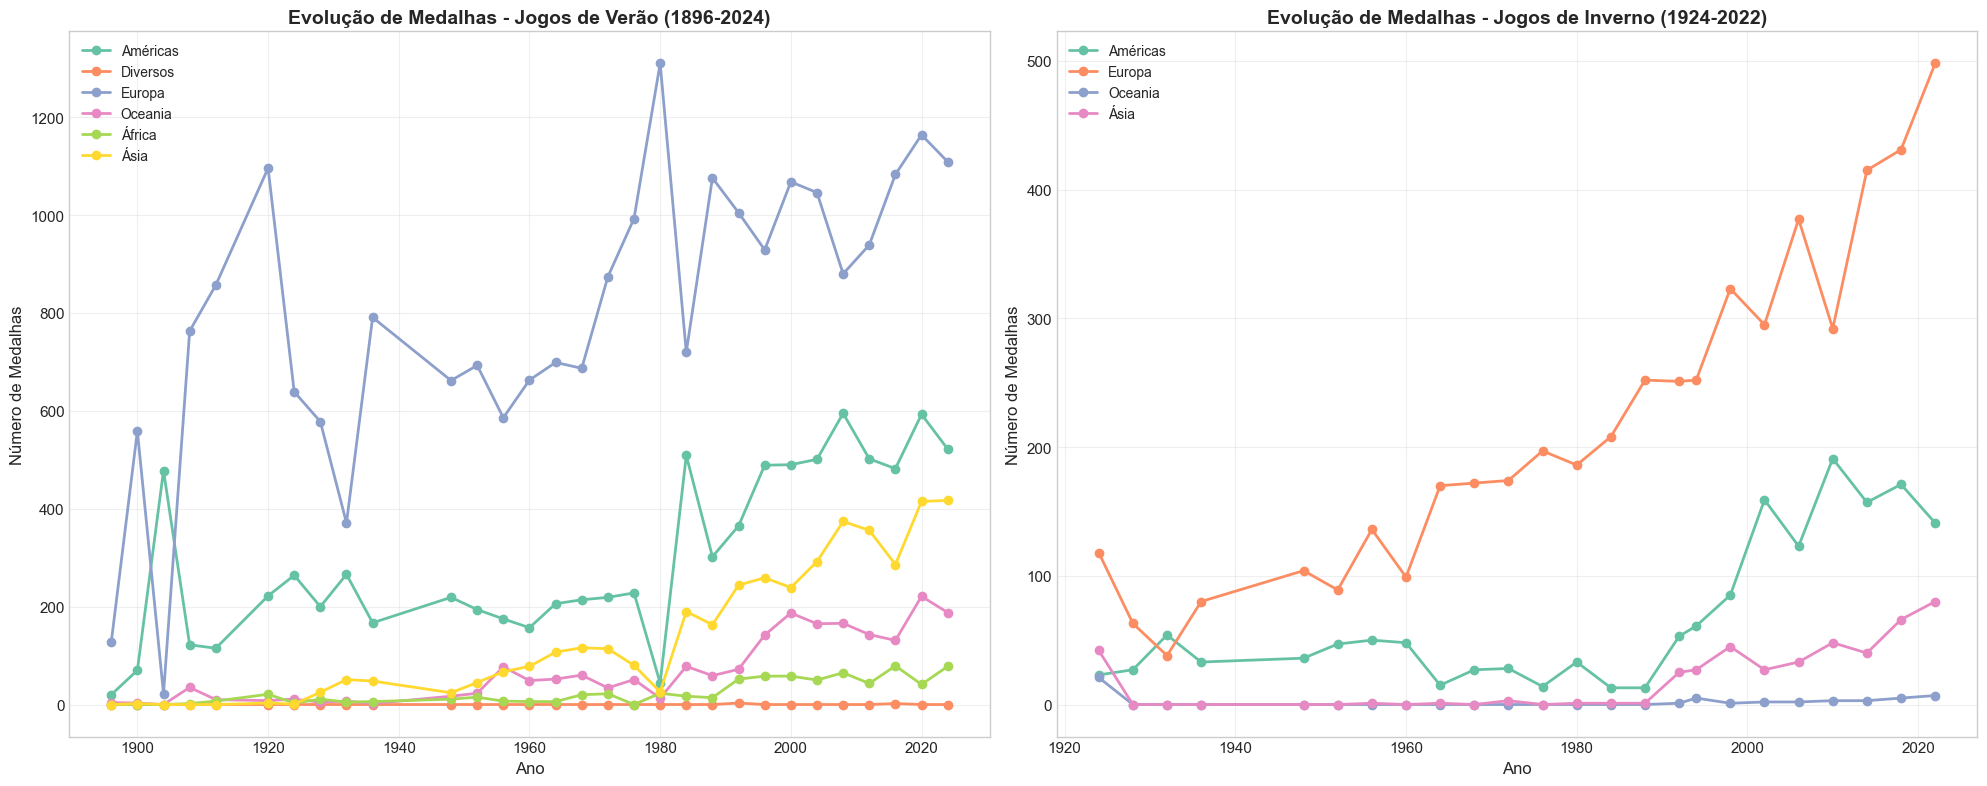


💾 Gold: medals_por_continente.parquet
💾 Gold: medals_evolucao_temporal_summer.parquet
💾 Gold: medals_evolucao_temporal_winter.parquet


In [52]:
print('='*80)
print('2.1 - DISTRIBUIÇÃO')
print('='*80)

# Total por continente
medals_cont=df_medals.groupby('continent')['medal'].count().sort_values(ascending=False)
print('\nTotal por continente:')
for c,n in medals_cont.items():print(f'{c:12}: {n:,}')

# Pizza com nota sobre Diversos
fig,ax=plt.subplots(figsize=(10,10))
wedges,texts,autotexts=ax.pie(medals_cont.values,labels=medals_cont.index,autopct='%1.1f%%',startangle=90)
ax.set_title('Distribuição Total de Medalhas por Continente (1896-2024)',fontsize=14,fontweight='bold')
# Adicionar nota explicativa sobre Diversos
plt.text(0.5,-1.15,'* Diversos: Atletas sem país definido (IOA=Atletas Olímpicos Independentes, IOP=Participantes Olímpicos Independentes)',
         ha='center',fontsize=9,style='italic',transform=ax.transAxes,wrap=True)
plt.tight_layout()
plt.savefig(OUTPUTS_PATH/'figures'/'parte2_pizza_continente.png',dpi=300,bbox_inches='tight')
print('\n💾 Gráfico: parte2_pizza_continente.png')
plt.show()

# Evolução temporal - SEPARANDO VERÃO E INVERNO para evitar instabilidade
df_summer=df_medals[df_medals['game_season']=='Summer']
df_winter=df_medals[df_medals['game_season']=='Winter']

medals_year_summer=df_summer.groupby(['game_year','continent']).size().unstack(fill_value=0)
medals_year_winter=df_winter.groupby(['game_year','continent']).size().unstack(fill_value=0)

# Gráfico Jogos de Verão
fig,axes=plt.subplots(1,2,figsize=(20,8))

for cont in medals_year_summer.columns:
    axes[0].plot(medals_year_summer.index,medals_year_summer[cont],marker='o',label=cont,linewidth=2)

# Anotar pontos destoantes no Verão
# 1916, 1940, 1944 - Guerras Mundiais
if 'Diversos' in medals_year_summer.columns:
    # Destacar quando Diversos teve picos
    diversos_data=medals_year_summer['Diversos']
    if diversos_data.max()>0:
        max_year=diversos_data.idxmax()
        max_val=diversos_data.max()
        if max_val>10:
            axes[0].annotate(f'Atletas\nIndependentes',xy=(max_year,max_val),
                           xytext=(max_year-8,max_val+50),fontsize=9,
                           arrowprops=dict(arrowstyle='->',color='gray',lw=1.5),
                           bbox=dict(boxstyle='round,pad=0.5',facecolor='yellow',alpha=0.7))

axes[0].set_xlabel('Ano',fontsize=12)
axes[0].set_ylabel('Número de Medalhas',fontsize=12)
axes[0].set_title('Evolução de Medalhas - Jogos de Verão (1896-2024)',fontsize=14,fontweight='bold')
axes[0].legend(fontsize=10,loc='upper left')
axes[0].grid(True,alpha=0.3)

# Gráfico Jogos de Inverno
for cont in medals_year_winter.columns:
    axes[1].plot(medals_year_winter.index,medals_year_winter[cont],marker='o',label=cont,linewidth=2)

# Anotar nota sobre Diversos no Inverno se existir
if 'Diversos' in medals_year_winter.columns:
    diversos_winter=medals_year_winter['Diversos']
    if diversos_winter.max()>0:
        max_year_w=diversos_winter.idxmax()
        max_val_w=diversos_winter.max()
        if max_val_w>3:
            axes[1].annotate(f'Atletas\nIndependentes',xy=(max_year_w,max_val_w),
                           xytext=(max_year_w-8,max_val_w+10),fontsize=9,
                           arrowprops=dict(arrowstyle='->',color='gray',lw=1.5),
                           bbox=dict(boxstyle='round,pad=0.5',facecolor='yellow',alpha=0.7))

axes[1].set_xlabel('Ano',fontsize=12)
axes[1].set_ylabel('Número de Medalhas',fontsize=12)
axes[1].set_title('Evolução de Medalhas - Jogos de Inverno (1924-2022)',fontsize=14,fontweight='bold')
axes[1].legend(fontsize=10,loc='upper left')
axes[1].grid(True,alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUTS_PATH/'figures'/'parte2_evolucao_continente.png',dpi=300,bbox_inches='tight')
print('💾 Gráfico: parte2_evolucao_continente.png')
plt.show()

# Salvar Gold
medals_cont.to_frame('total').to_parquet(GOLD_PATH/'medals_por_continente.parquet')
medals_year_summer.to_parquet(GOLD_PATH/'medals_evolucao_temporal_summer.parquet')
medals_year_winter.to_parquet(GOLD_PATH/'medals_evolucao_temporal_winter.parquet')
print('\n💾 Gold: medals_por_continente.parquet')
print('💾 Gold: medals_evolucao_temporal_summer.parquet')
print('💾 Gold: medals_evolucao_temporal_winter.parquet')

## 📈 2.2 - Crescimento da Representação

2.2 - CRESCIMENTO DA REPRESENTAÇÃO

Estatísticas - JOGOS DE VERÃO (países participantes por continente):
Américas    : média=8.8, std=4.8, min=1, max=18
Diversos    : média=0.1, std=0.3, min=0, max=1
Europa      : média=23.8, std=9.3, min=4, max=40
Oceania     : média=1.9, std=0.7, min=0, max=3
África      : média=4.9, std=4.5, min=0, max=13
Ásia        : média=8.2, std=7.5, min=0, max=22

Estatísticas - JOGOS DE INVERNO (países participantes por continente):
Américas    : média=2.0, std=0.0, min=2, max=2
Europa      : média=14.2, std=4.1, min=8, max=22
Oceania     : média=0.5, std=0.7, min=0, max=2
Ásia        : média=1.8, std=1.7, min=0, max=5

💾 Gráfico: parte2_crescimento_representacao.png


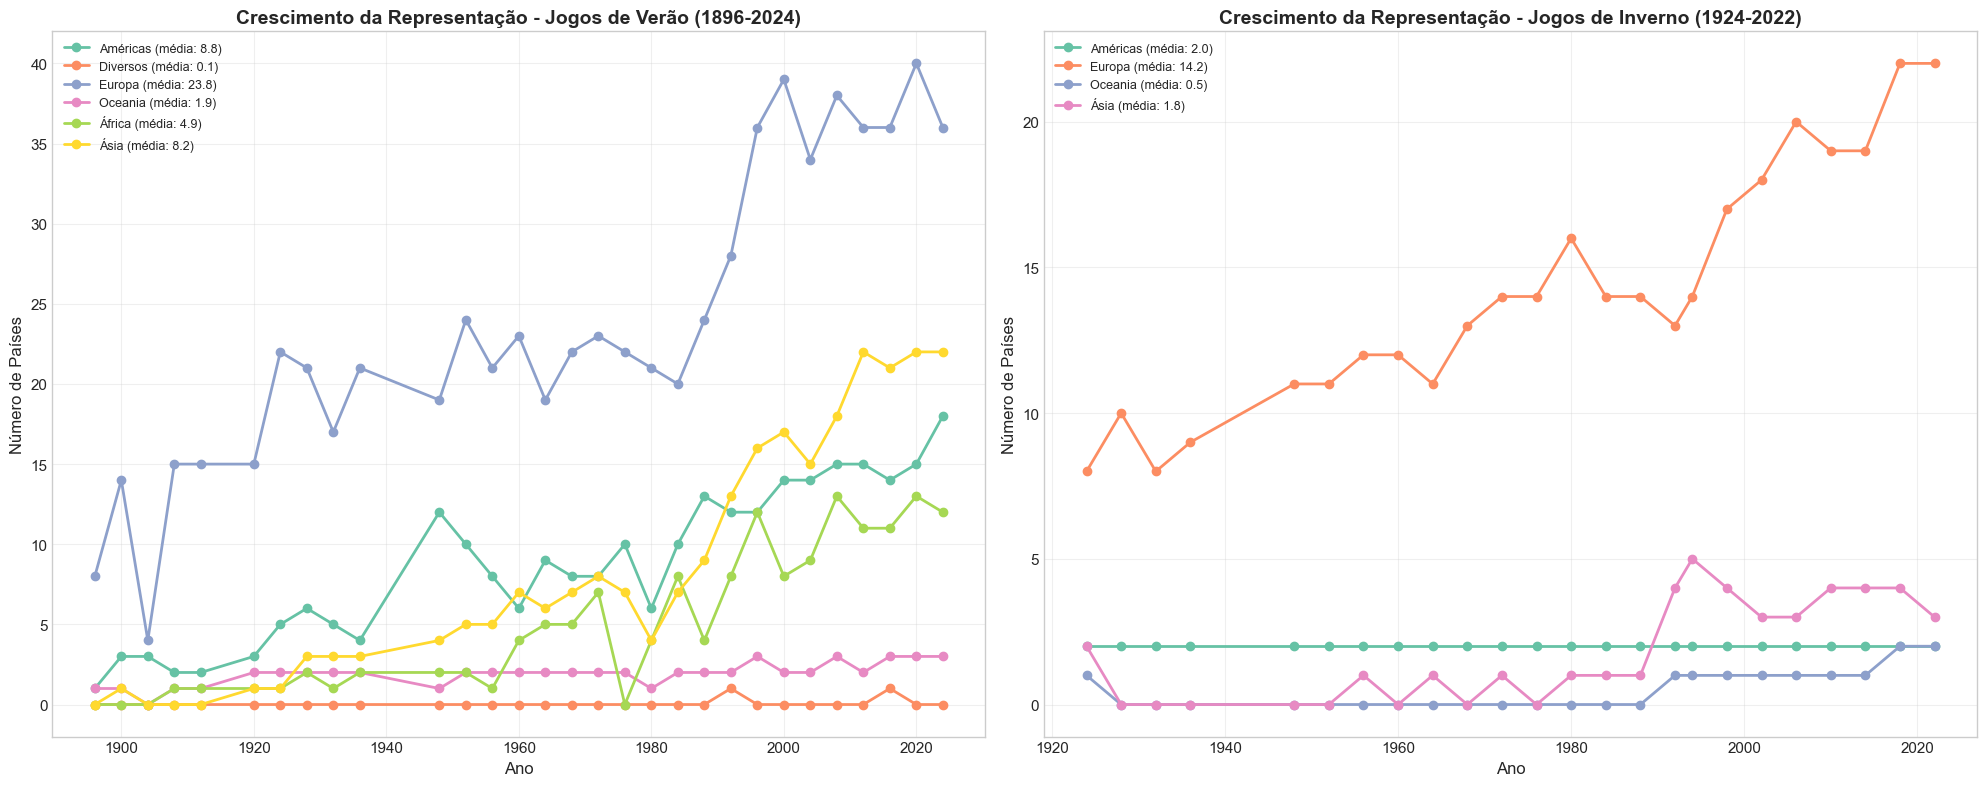

💾 Gold: crescimento_stats_summer.parquet
💾 Gold: crescimento_stats_winter.parquet


In [53]:
print('='*80)
print('2.2 - CRESCIMENTO DA REPRESENTAÇÃO')
print('='*80)

# Países por ano - SEPARANDO VERÃO E INVERNO
countries_year_summer=df_summer.groupby(['game_year','continent'])['country_noc'].nunique().unstack(fill_value=0)
countries_year_winter=df_winter.groupby(['game_year','continent'])['country_noc'].nunique().unstack(fill_value=0)

stats_summer=countries_year_summer.agg(['mean','std','min','max'])
stats_winter=countries_year_winter.agg(['mean','std','min','max'])

print('\nEstatísticas - JOGOS DE VERÃO (países participantes por continente):')
for cont in stats_summer.columns:
    print(f'{cont:12}: média={stats_summer.loc["mean",cont]:.1f}, std={stats_summer.loc["std",cont]:.1f}, min={stats_summer.loc["min",cont]:.0f}, max={stats_summer.loc["max",cont]:.0f}')

print('\nEstatísticas - JOGOS DE INVERNO (países participantes por continente):')
for cont in stats_winter.columns:
    print(f'{cont:12}: média={stats_winter.loc["mean",cont]:.1f}, std={stats_winter.loc["std",cont]:.1f}, min={stats_winter.loc["min",cont]:.0f}, max={stats_winter.loc["max",cont]:.0f}')

# Gráficos lado a lado
fig,axes=plt.subplots(1,2,figsize=(20,8))

# Verão
for cont in countries_year_summer.columns:
    axes[0].plot(countries_year_summer.index,countries_year_summer[cont],marker='o',
                 label=f'{cont} (média: {stats_summer.loc["mean",cont]:.1f})',linewidth=2)

# Anotar explicação sobre Diversos no gráfico de Verão
if 'Diversos' in countries_year_summer.columns:
    diversos_countries=countries_year_summer['Diversos']
    if diversos_countries.max()>0:
        # Encontrar ano com mais "países" em Diversos
        max_year=diversos_countries.idxmax()
        max_val=diversos_countries.max()
        if max_val>=1:
            axes[0].annotate('Atletas sem país\n(IOA, IOP)',xy=(max_year,max_val),
                           xytext=(max_year-10,max_val+3),fontsize=9,
                           arrowprops=dict(arrowstyle='->',color='gray',lw=1.5),
                           bbox=dict(boxstyle='round,pad=0.5',facecolor='yellow',alpha=0.7))

axes[0].set_xlabel('Ano',fontsize=12)
axes[0].set_ylabel('Número de Países',fontsize=12)
axes[0].set_title('Crescimento da Representação - Jogos de Verão (1896-2024)',fontsize=14,fontweight='bold')
axes[0].legend(fontsize=9,loc='upper left')
axes[0].grid(True,alpha=0.3)

# Inverno
for cont in countries_year_winter.columns:
    axes[1].plot(countries_year_winter.index,countries_year_winter[cont],marker='o',
                 label=f'{cont} (média: {stats_winter.loc["mean",cont]:.1f})',linewidth=2)

# Anotar explicação sobre Diversos no gráfico de Inverno se existir
if 'Diversos' in countries_year_winter.columns:
    diversos_countries_w=countries_year_winter['Diversos']
    if diversos_countries_w.max()>0:
        max_year_w=diversos_countries_w.idxmax()
        max_val_w=diversos_countries_w.max()
        if max_val_w>=1:
            axes[1].annotate('Atletas sem país\n(IOA, IOP)',xy=(max_year_w,max_val_w),
                           xytext=(max_year_w-10,max_val_w+2),fontsize=9,
                           arrowprops=dict(arrowstyle='->',color='gray',lw=1.5),
                           bbox=dict(boxstyle='round,pad=0.5',facecolor='yellow',alpha=0.7))

axes[1].set_xlabel('Ano',fontsize=12)
axes[1].set_ylabel('Número de Países',fontsize=12)
axes[1].set_title('Crescimento da Representação - Jogos de Inverno (1924-2022)',fontsize=14,fontweight='bold')
axes[1].legend(fontsize=9,loc='upper left')
axes[1].grid(True,alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUTS_PATH/'figures'/'parte2_crescimento_representacao.png',dpi=300,bbox_inches='tight')
print('\n💾 Gráfico: parte2_crescimento_representacao.png')
plt.show()

# Salvar
stats_summer.to_parquet(GOLD_PATH/'crescimento_stats_summer.parquet')
stats_winter.to_parquet(GOLD_PATH/'crescimento_stats_winter.parquet')
countries_year_summer.to_parquet(GOLD_PATH/'crescimento_temporal_summer.parquet')
countries_year_winter.to_parquet(GOLD_PATH/'crescimento_temporal_winter.parquet')
print('💾 Gold: crescimento_stats_summer.parquet')
print('💾 Gold: crescimento_stats_winter.parquet')

## 👩 2.3 - Participação Feminina

2.3 - PARTICIPAÇÃO FEMININA

Valores de sexo encontrados: ['Male' 'Female']

% Participação Feminina VERÃO (últimas 5 edições):
continent  Américas  Diversos  Europa  Oceania  África  Ásia
game_year                                                   
2008           44.5       0.0    40.8     53.6    38.5  56.1
2012           55.0       0.0    42.7     51.7    39.5  48.9
2016           51.7       0.0    46.7     48.9    25.3  52.4
2020           57.3       0.0    46.7     44.3    43.9  48.7
2024           61.5       0.0    44.5     62.2    20.5  51.3

% Participação Feminina INVERNO (últimas 5 edições):
continent  Américas  Europa  Oceania  Ásia
game_year                                 
2006           62.6    36.6     50.0  54.5
2010           43.5    42.1     66.7  60.4
2014           54.1    40.7     66.7  45.0
2018           55.6    40.8     20.0  51.5
2022           63.8    39.6     71.4  51.2



💾 Gráfico: parte2_participacao_feminina.png


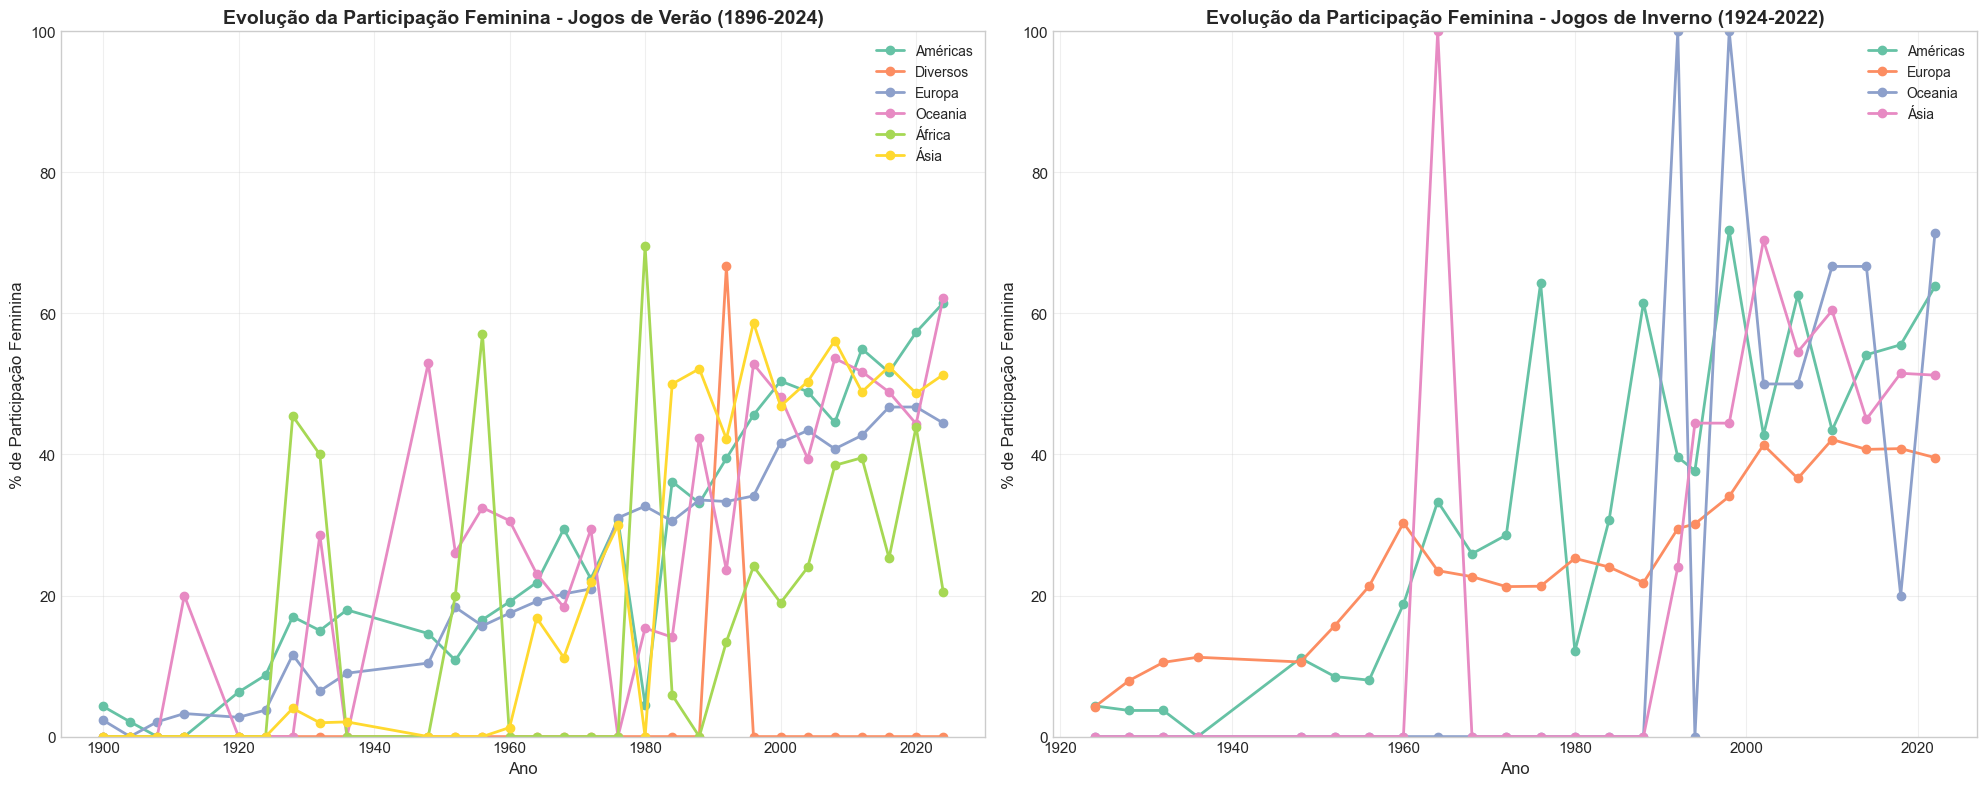

💾 Gold: participacao_feminina_summer.parquet
💾 Gold: participacao_feminina_winter.parquet


In [54]:
print('='*80)
print('2.3 - PARTICIPAÇÃO FEMININA')
print('='*80)

# Filtrar dados com sexo conhecido
df_gender=df_medals[df_medals['athlete_sex'].notna()].copy()
# Normalizar valores para Female/Male
df_gender['athlete_sex']=df_gender['athlete_sex'].str.strip().str.capitalize()

# Verificar valores únicos
print('\nValores de sexo encontrados:', df_gender['athlete_sex'].unique())

# SEPARAR POR TEMPORADA
df_gender_summer=df_gender[df_gender['game_season']=='Summer']
df_gender_winter=df_gender[df_gender['game_season']=='Winter']

# Verificar se temos dados femininos
female_col=None
for col in ['Female','F','female']:
    if col in df_gender['athlete_sex'].unique():
        female_col=col
        break

if female_col:
    # Calcular para VERÃO
    gender_year_cont_summer=df_gender_summer.groupby(['game_year','continent','athlete_sex']).size().reset_index(name='count')
    total_by_year_cont_summer=gender_year_cont_summer.groupby(['game_year','continent'])['count'].sum().reset_index(name='total')
    female_summer=gender_year_cont_summer[gender_year_cont_summer['athlete_sex']==female_col]
    
    # Merge e calcular percentual
    female_pct_data_summer=female_summer.merge(total_by_year_cont_summer,on=['game_year','continent'])
    female_pct_data_summer['pct']=(female_pct_data_summer['count']/female_pct_data_summer['total']*100)
    female_pct_summer=female_pct_data_summer.pivot(index='game_year',columns='continent',values='pct').fillna(0)
    
    # Calcular para INVERNO
    if len(df_gender_winter)>0:
        gender_year_cont_winter=df_gender_winter.groupby(['game_year','continent','athlete_sex']).size().reset_index(name='count')
        total_by_year_cont_winter=gender_year_cont_winter.groupby(['game_year','continent'])['count'].sum().reset_index(name='total')
        female_winter=gender_year_cont_winter[gender_year_cont_winter['athlete_sex']==female_col]
        
        female_pct_data_winter=female_winter.merge(total_by_year_cont_winter,on=['game_year','continent'])
        female_pct_data_winter['pct']=(female_pct_data_winter['count']/female_pct_data_winter['total']*100)
        female_pct_winter=female_pct_data_winter.pivot(index='game_year',columns='continent',values='pct').fillna(0)
    else:
        female_pct_winter=pd.DataFrame()
    
    print('\n% Participação Feminina VERÃO (últimas 5 edições):')
    print(female_pct_summer.tail(5).round(1))
    
    if len(female_pct_winter)>0:
        print('\n% Participação Feminina INVERNO (últimas 5 edições):')
        print(female_pct_winter.tail(5).round(1))
    
    # Gráficos lado a lado
    fig,axes=plt.subplots(1,2,figsize=(20,8))
    
    # Verão
    for cont in female_pct_summer.columns:
        axes[0].plot(female_pct_summer.index,female_pct_summer[cont],marker='o',label=cont,linewidth=2)
    
    # Anotar pontos destoantes no gráfico de Verão
    # Identificar anos com picos ou quedas anormais
    for cont in female_pct_summer.columns:
        if cont=='Diversos':
            continue
        data=female_pct_summer[cont]
        # Encontrar variações grandes (>20% em um único salto)
        diff=data.diff().abs()
        outliers=diff[diff>20]
        for year in outliers.index:
            if year>1900:  # Evitar anos muito antigos
                val=data[year]
                prev_val=data[year-4] if year-4 in data.index else 0
                if val>prev_val+15:  # Salto significativo
                    axes[0].annotate(f'{year}\n+{val-prev_val:.0f}%',xy=(year,val),
                                   xytext=(year+2,val-8),fontsize=8,
                                   arrowprops=dict(arrowstyle='->',color='red',lw=1),
                                   bbox=dict(boxstyle='round,pad=0.3',facecolor='white',edgecolor='red',alpha=0.8))
    
    # Anotar explicação sobre Diversos se existir
    if 'Diversos' in female_pct_summer.columns:
        diversos_fem=female_pct_summer['Diversos']
        if diversos_fem.max()>0:
            max_year=diversos_fem.idxmax()
            max_val=diversos_fem[max_year]
            if max_val>10:
                axes[0].annotate('Atletas\nIndependentes',xy=(max_year,max_val),
                               xytext=(max_year-8,max_val+10),fontsize=9,
                               arrowprops=dict(arrowstyle='->',color='gray',lw=1.5),
                               bbox=dict(boxstyle='round,pad=0.5',facecolor='yellow',alpha=0.7))
    
    axes[0].set_xlabel('Ano',fontsize=12)
    axes[0].set_ylabel('% de Participação Feminina',fontsize=12)
    axes[0].set_title('Evolução da Participação Feminina - Jogos de Verão (1896-2024)',fontsize=14,fontweight='bold')
    axes[0].legend(fontsize=10,loc='upper left')
    axes[0].grid(True,alpha=0.3)
    axes[0].set_ylim(0,100)
    
    # Inverno
    if len(female_pct_winter)>0:
        for cont in female_pct_winter.columns:
            axes[1].plot(female_pct_winter.index,female_pct_winter[cont],marker='o',label=cont,linewidth=2)
        
        # Anotar pontos destoantes no Inverno
        for cont in female_pct_winter.columns:
            if cont=='Diversos':
                continue
            data=female_pct_winter[cont]
            diff=data.diff().abs()
            outliers=diff[diff>20]
            for year in outliers.index:
                if year>1924:
                    val=data[year]
                    prev_val=data[year-4] if year-4 in data.index else 0
                    if val>prev_val+15:
                        axes[1].annotate(f'{year}\n+{val-prev_val:.0f}%',xy=(year,val),
                                       xytext=(year+2,val-8),fontsize=8,
                                       arrowprops=dict(arrowstyle='->',color='red',lw=1),
                                       bbox=dict(boxstyle='round,pad=0.3',facecolor='white',edgecolor='red',alpha=0.8))
        
        # Anotar Diversos no Inverno
        if 'Diversos' in female_pct_winter.columns:
            diversos_fem_w=female_pct_winter['Diversos']
            if diversos_fem_w.max()>0:
                max_year_w=diversos_fem_w.idxmax()
                max_val_w=diversos_fem_w[max_year_w]
                if max_val_w>10:
                    axes[1].annotate('Atletas\nIndependentes',xy=(max_year_w,max_val_w),
                                   xytext=(max_year_w-8,max_val_w+10),fontsize=9,
                                   arrowprops=dict(arrowstyle='->',color='gray',lw=1.5),
                                   bbox=dict(boxstyle='round,pad=0.5',facecolor='yellow',alpha=0.7))
        
        axes[1].set_xlabel('Ano',fontsize=12)
        axes[1].set_ylabel('% de Participação Feminina',fontsize=12)
        axes[1].set_title('Evolução da Participação Feminina - Jogos de Inverno (1924-2022)',fontsize=14,fontweight='bold')
        axes[1].legend(fontsize=10,loc='upper left')
        axes[1].grid(True,alpha=0.3)
        axes[1].set_ylim(0,100)
    else:
        axes[1].text(0.5,0.5,'Dados de Inverno\nnão disponíveis',ha='center',va='center',fontsize=14,transform=axes[1].transAxes)
        axes[1].set_xlim(0,1)
        axes[1].set_ylim(0,1)
    
    plt.tight_layout()
    plt.savefig(OUTPUTS_PATH/'figures'/'parte2_participacao_feminina.png',dpi=300,bbox_inches='tight')
    print('\n💾 Gráfico: parte2_participacao_feminina.png')
    plt.show()
    
    # Salvar
    female_pct_summer.to_parquet(GOLD_PATH/'participacao_feminina_summer.parquet')
    if len(female_pct_winter)>0:
        female_pct_winter.to_parquet(GOLD_PATH/'participacao_feminina_winter.parquet')
    print('💾 Gold: participacao_feminina_summer.parquet')
    if len(female_pct_winter)>0:
        print('💾 Gold: participacao_feminina_winter.parquet')
else:
    print('⚠️ Dados de sexo não disponíveis')

## 🏅 2.4 - Modalidades Mais Fortes

2.4 - MODALIDADES MAIS FORTES

Américas:
   1. Athletics                      - 1,848 medalhas
   2. Swimming                       - 1,378 medalhas
   3. Ice Hockey                     - 767 medalhas
   4. Football                       - 668 medalhas
   5. Rowing                         - 660 medalhas
   6. Basketball                     - 535 medalhas
   7. Volleyball                     - 399 medalhas
   8. Boxing                         - 291 medalhas
   9. Shooting                       - 261 medalhas
  10. Artistic Gymnastics            - 239 medalhas

Europa:
   1. Athletics                      - 2,286 medalhas
   2. Rowing                         - 2,241 medalhas
   3. Artistic Gymnastics            - 1,768 medalhas
   4. Fencing                        - 1,700 medalhas
   5. Football                       - 1,320 medalhas
   6. Swimming                       - 1,290 medalhas
   7. Handball                       - 1,160 medalhas
   8. Ice Hockey                     - 1,107 med


💾 Gráfico: parte2_modalidades_continente.png


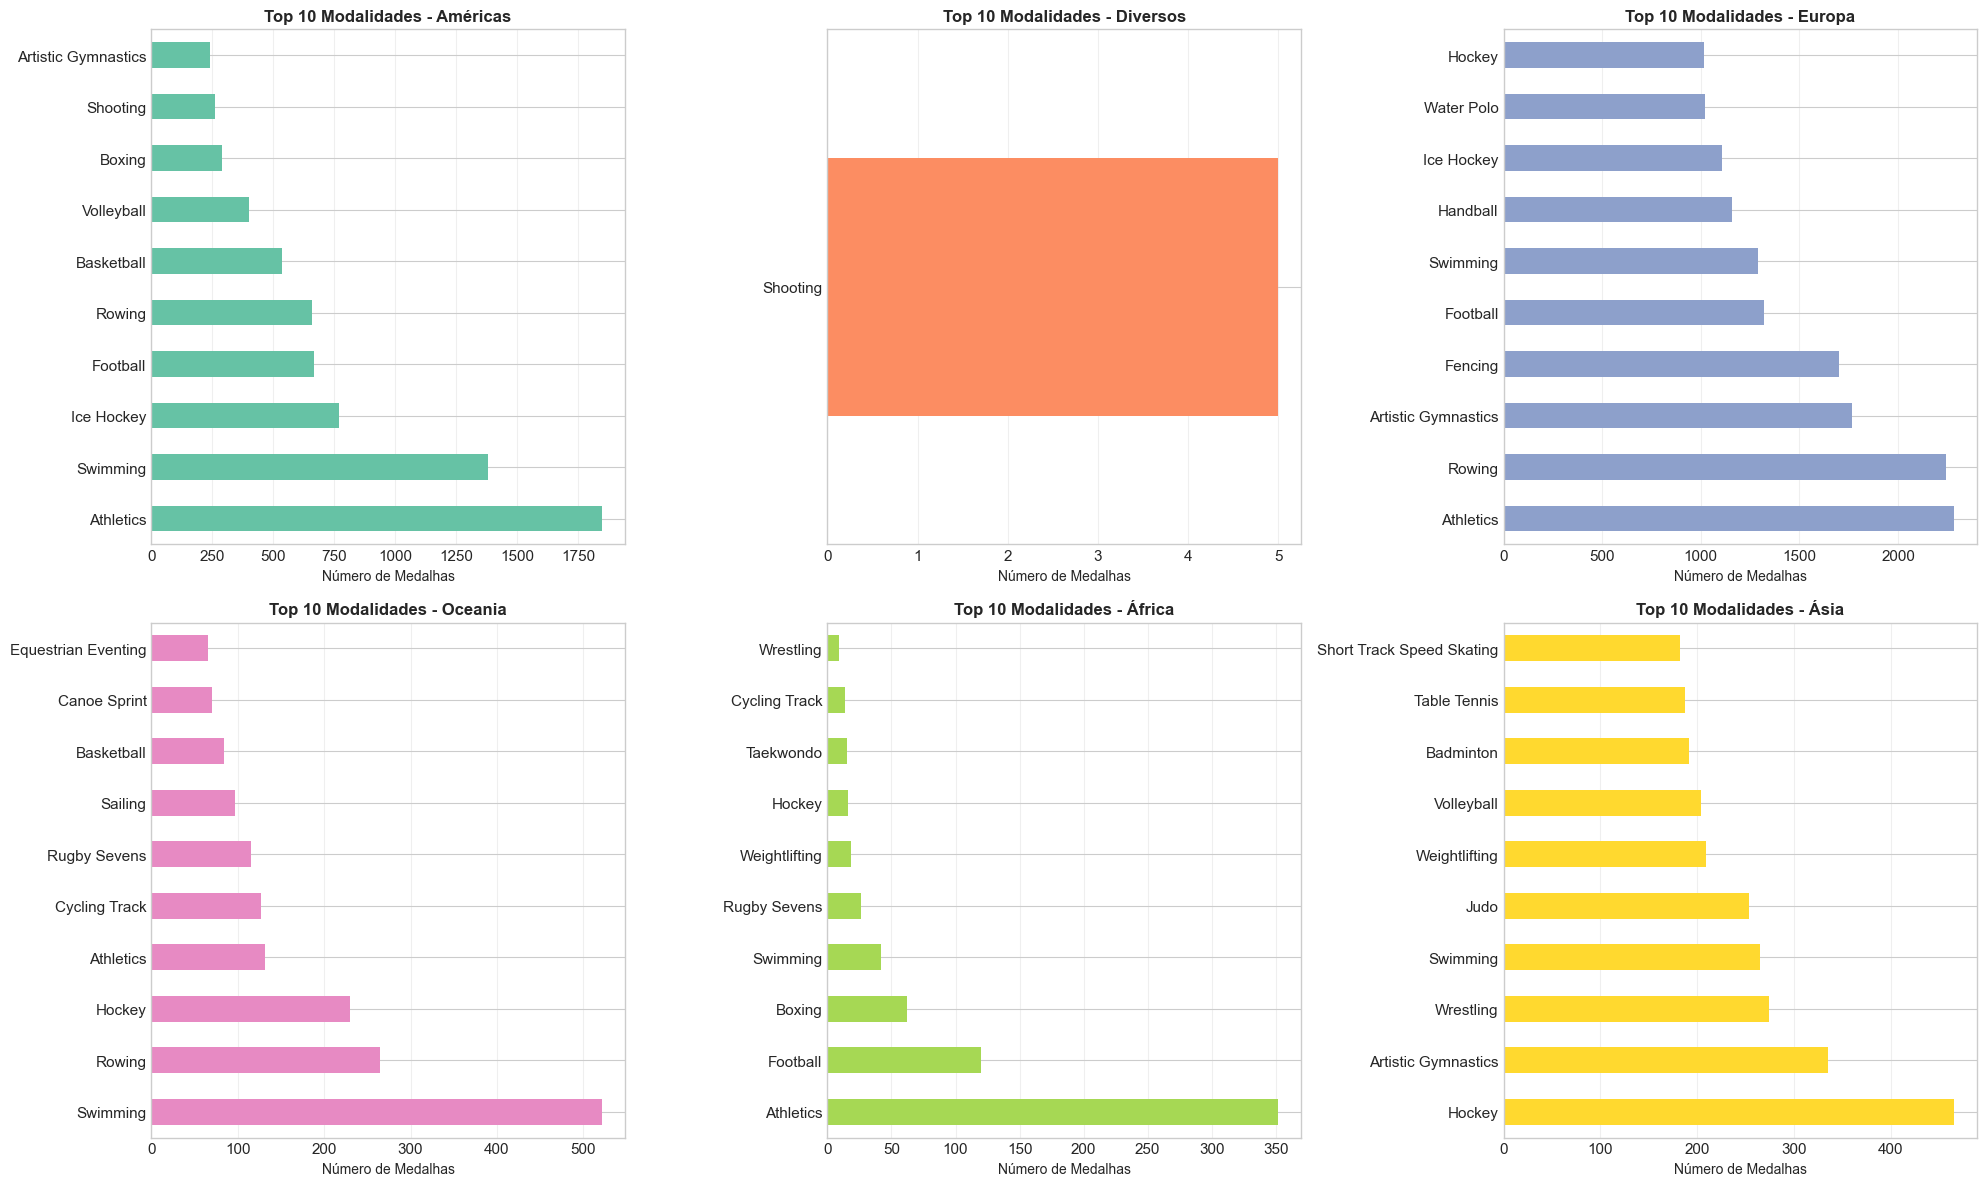

💾 Gold: modalidades_fortes.parquet


In [55]:
print('='*80)
print('2.4 - MODALIDADES MAIS FORTES')
print('='*80)

# Top 10 por continente
top_sports={}
for cont in df_medals['continent'].unique():
    df_c=df_medals[df_medals['continent']==cont]
    top10=df_c['event_discipline'].value_counts().head(10)
    top_sports[cont]=top10
    print(f'\n{cont}:')
    for i,(sport,count) in enumerate(top10.items(),1):
        print(f'  {i:2}. {sport:30} - {count:,} medalhas')

# Visualizar
fig,axes=plt.subplots(2,3,figsize=(20,12))
axes=axes.flatten()

for idx,(cont,sports) in enumerate(sorted(top_sports.items())):
    if idx<6:
        sports.plot(kind='barh',ax=axes[idx],color=sns.color_palette('Set2')[idx])
        axes[idx].set_title(f'Top 10 Modalidades - {cont}',fontsize=12,fontweight='bold')
        axes[idx].set_xlabel('Número de Medalhas',fontsize=10)
        axes[idx].set_ylabel('')
        axes[idx].grid(axis='x',alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUTS_PATH/'figures'/'parte2_modalidades_continente.png',dpi=300,bbox_inches='tight')
print('\n💾 Gráfico: parte2_modalidades_continente.png')
plt.show()

# Salvar
df_top=pd.DataFrame(top_sports)
df_top.to_parquet(GOLD_PATH/'modalidades_fortes.parquet')
print('💾 Gold: modalidades_fortes.parquet')

## 📊 2.5 - Crescimento nas Medalhas (1896-2024)

2.5 - CRESCIMENTO 1896-2024

Comparação de períodos:
           1896-1920  2000-2024  crescimento_%
continent                                     
Ásia             5.0       2673        53360.0
Oceania         60.0       1223         1938.3
África          30.0        414         1280.0
Américas      1027.0       4627          350.5
Europa        3424.0       9597          180.3
Diversos         0.0          2            NaN

💾 Gráfico: parte2_crescimento_1896_2024.png


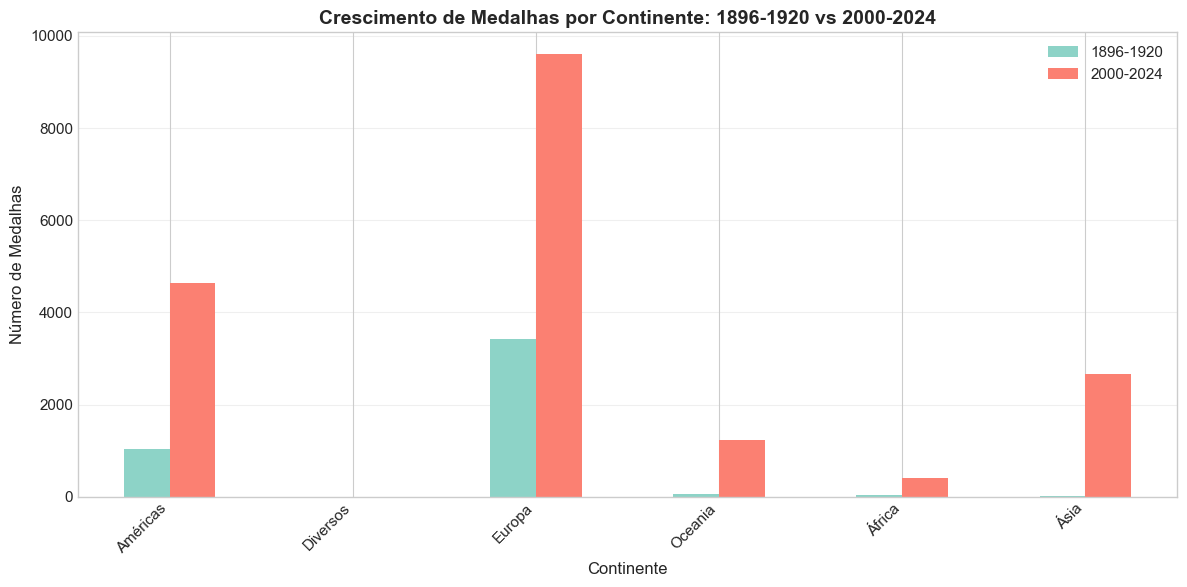

💾 Gold: crescimento_periodos.parquet


In [56]:
print('='*80)
print('2.5 - CRESCIMENTO 1896-2024')
print('='*80)

# Comparar períodos
primerio=df_medals[df_medals['game_year']<=1920]
ultimo=df_medals[df_medals['game_year']>=2000]

crescimento=pd.DataFrame({
    '1896-1920':primerio.groupby('continent').size(),
    '2000-2024':ultimo.groupby('continent').size()
})
crescimento=crescimento.fillna(0)
crescimento['crescimento_%']=((crescimento['2000-2024']/crescimento['1896-1920'])-1)*100
crescimento['crescimento_%']=crescimento['crescimento_%'].replace([np.inf,-np.inf],np.nan)

print('\nComparação de períodos:')
print(crescimento.sort_values('crescimento_%',ascending=False).round(1))

# Gráfico
fig,ax=plt.subplots(figsize=(12,6))
crescimento[['1896-1920','2000-2024']].plot(kind='bar',ax=ax,color=['#8dd3c7','#fb8072'])
ax.set_title('Crescimento de Medalhas por Continente: 1896-1920 vs 2000-2024',fontsize=14,fontweight='bold')
ax.set_ylabel('Número de Medalhas',fontsize=12)
ax.set_xlabel('Continente',fontsize=12)
ax.set_xticklabels(crescimento.index,rotation=45,ha='right')
ax.legend(['1896-1920','2000-2024'])
ax.grid(axis='y',alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUTS_PATH/'figures'/'parte2_crescimento_1896_2024.png',dpi=300,bbox_inches='tight')
print('\n💾 Gráfico: parte2_crescimento_1896_2024.png')
plt.show()

# Salvar
crescimento.to_parquet(GOLD_PATH/'crescimento_periodos.parquet')
print('💾 Gold: crescimento_periodos.parquet')

## 💾 Gerando Metadados

In [57]:
print('='*80)
print('GERANDO METADADOS')
print('='*80)

def save_metadata(filename,name,desc):
    meta={'nome':name,'descricao':desc,'periodo':'1896-2024','fonte':'Olympedia + Olympics.com','criado_em':datetime.now().isoformat()}
    with open(METADATA_PATH/f'{filename}_metadata.json','w') as f:json.dump(meta,f,indent=2)
    print(f'✅ {filename}_metadata.json')

save_metadata('medals_por_continente','Medalhas por Continente','Total de medalhas acumuladas por continente')
save_metadata('crescimento_stats','Estatísticas de Crescimento','Média, desvio padrão, min, max de países por continente')
save_metadata('participacao_feminina','Participação Feminina','Percentual de mulheres por continente ao longo do tempo')
save_metadata('modalidades_fortes','Modalidades Mais Fortes','Top 10 esportes que rendem mais medalhas por continente')
save_metadata('crescimento_periodos','Crescimento por Períodos','Comparação 1896-1920 vs 2000-2024')

print('\n✅ PARTE 2 COMPLETA!')

GERANDO METADADOS
✅ medals_por_continente_metadata.json
✅ crescimento_stats_metadata.json
✅ participacao_feminina_metadata.json
✅ modalidades_fortes_metadata.json
✅ crescimento_periodos_metadata.json

✅ PARTE 2 COMPLETA!


## ✅ Análise Concluída!

### Outputs Gerados:

**Bronze:**
- medals_integrated.parquet

**Gold:**
- medals_por_continente.parquet
- medals_evolucao_temporal_summer.parquet (Jogos de Verão)
- medals_evolucao_temporal_winter.parquet (Jogos de Inverno)
- crescimento_stats_summer.parquet (Estatísticas Verão)
- crescimento_stats_winter.parquet (Estatísticas Inverno)
- crescimento_temporal_summer.parquet (Crescimento Verão)
- crescimento_temporal_winter.parquet (Crescimento Inverno)
- participacao_feminina_summer.parquet (% Feminina Verão)
- participacao_feminina_winter.parquet (% Feminina Inverno)
- modalidades_fortes.parquet
- crescimento_periodos.parquet

**Figuras:**
- parte2_pizza_continente.png
- parte2_evolucao_continente.png (Verão e Inverno lado a lado)
- parte2_crescimento_representacao.png (Verão e Inverno lado a lado)
- parte2_participacao_feminina.png (Verão e Inverno lado a lado)
- parte2_modalidades_continente.png
- parte2_crescimento_1896_2024.png

**Metadados:**
- 5 arquivos JSON em metadata/parte2/

### 📝 Nota Importante:

Os gráficos de evolução temporal foram separados entre **Jogos de Verão** e **Jogos de Inverno** para evitar instabilidade nos dados. A partir de 1994, os Jogos Olímpicos passaram a ser realizados em anos diferentes (intercalados), causando grandes oscilações quando analisados juntos.